# 02 · Análise exploratória (EDA)
[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jessicapmartins/segmentacao-clientes-olist/blob/main/notebooks/02_eda.ipynb)

Roteiro em 6 passos (ver o capítulo 2 do caderno de revisão). Ao final de cada passo, escreva **o que você aprendeu** em uma frase.

In [1]:
import sqlite3, pandas as pd
from google.colab import drive
drive.mount('/content/drive')
DADOS = '/content/drive/MyDrive/03_Portfolio/Projetos_ML/01_segmentacao-clientes-olist/dados'
con = sqlite3.connect(f'{DADOS}/olist.db')
def q(sql):
    """Roda uma consulta SQL no banco da Olist e devolve um DataFrame."""
    return pd.read_sql(sql, con)

import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

Mounted at /content/drive


## 1. Conhecer a base
Monte uma visão por pedido juntando pedidos, clientes, pagamentos e avaliações (pode reaproveitar o SQL do notebook 01). Veja `shape`, `info()` e `head()`.

In [2]:
pedidos = q('''
WITH itens AS (                                   -- produtos e frete por pedido
    SELECT i.order_id,
           COUNT(*)              AS qtd_itens,
           SUM(i.price)          AS valor_produtos,
           SUM(i.freight_value)  AS frete,
           MIN(v.seller_state)   AS estado_vendedor
    FROM itens_pedido i
    JOIN vendedores v ON i.seller_id = v.seller_id
    GROUP BY i.order_id
),
pago AS (                                         -- pagamento por pedido
    SELECT order_id,
           SUM(payment_value)                                        AS valor_pago,
           MAX(payment_installments)                                 AS parcelas,
           MIN(CASE WHEN payment_sequential = 1 THEN payment_type END) AS tipo_pagamento
    FROM pagamentos
    GROUP BY order_id
),
nota AS (
    SELECT order_id, AVG(review_score) AS nota FROM avaliacoes GROUP BY order_id
)
SELECT p.order_id, p.order_status,
       p.order_purchase_timestamp       AS data_compra,
       p.order_delivered_customer_date  AS data_entrega,
       p.order_estimated_delivery_date  AS data_estimada,
       c.customer_unique_id, c.customer_state AS estado_cliente,
       i.estado_vendedor, i.qtd_itens, i.valor_produtos, i.frete,
       pg.valor_pago, pg.parcelas, pg.tipo_pagamento, n.nota
FROM pedidos p
JOIN clientes c   ON p.customer_id = c.customer_id
LEFT JOIN itens i ON p.order_id = i.order_id      -- LEFT: mantém pedidos sem item (vamos ver na seção 2)
LEFT JOIN pago pg ON p.order_id = pg.order_id
LEFT JOIN nota n  ON p.order_id = n.order_id
''')

# Datas chegam como texto. Aqui viram data de verdade
for col in ['data_compra', 'data_entrega', 'data_estimada']:
    pedidos[col] = pd.to_datetime(pedidos[col])

print(pedidos.shape)          # (linhas, colunas)
pedidos.info()
pedidos.head()

(99441, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            99441 non-null  object        
 1   order_status        99441 non-null  object        
 2   data_compra         99441 non-null  datetime64[ns]
 3   data_entrega        96476 non-null  datetime64[ns]
 4   data_estimada       99441 non-null  datetime64[ns]
 5   customer_unique_id  99441 non-null  object        
 6   estado_cliente      99441 non-null  object        
 7   estado_vendedor     98666 non-null  object        
 8   qtd_itens           98666 non-null  float64       
 9   valor_produtos      98666 non-null  float64       
 10  frete               98666 non-null  float64       
 11  valor_pago          99440 non-null  float64       
 12  parcelas            99440 non-null  float64       
 13  tipo_pagamento      99360 non-null

,order_id,order_status,data_compra,data_entrega,data_estimada,customer_unique_id,estado_cliente,estado_vendedor,qtd_itens,valor_produtos,frete,valor_pago,parcelas,tipo_pagamento,nota
0,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-25 10:35:35,2017-06-05,861eff4711a542e4b93843c6dd7febb0,SP,SP,1.0,124.99,21.88,146.87,2.0,credit_card,4.0
1,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-29 12:41:19,2018-02-06,290c77bc529b7ac935b93aa66c333dc3,SP,SC,1.0,289.00,46.48,335.48,8.0,credit_card,5.0
2,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-06-14 17:58:51,2018-06-13,060e732b5b29e8181a18229c7b0b2b5e,SP,SP,1.0,139.94,17.79,157.73,7.0,credit_card,5.0
3,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-28 16:04:25,2018-04-10,259dac757896d24d7702b9acbbff3f3c,SP,SP,1.0,149.94,23.36,173.30,1.0,credit_card,5.0
4,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-08-09 20:55:48,2018-08-15,345ecd01c38d18a9036ed96c73b8d066,SP,SP,1.0,230.00,22.25,252.25,8.0,credit_card,5.0


## 2. Qualidade dos dados
Faltantes por coluna, duplicados, datas em formato errado, pedidos cancelados.

In [3]:
# 1) % de valores faltantes por coluna
print('--- % faltantes ---')
print((pedidos.isna().mean() * 100).round(2).sort_values(ascending=False))

# 2) Pedidos duplicados?
print('\nPedidos duplicados:', pedidos['order_id'].duplicated().sum())

# 3) Status dos pedidos
print('\n--- Status ---')
print(pedidos['order_status'].value_counts())

# 4) Datas incoerentes: entrega ANTES da compra
print('\nEntrega antes da compra:', (pedidos['data_entrega'] < pedidos['data_compra']).sum())

--- % faltantes ---
data_entrega          2.98
qtd_itens             0.78
estado_vendedor       0.78
frete                 0.78
valor_produtos        0.78
nota                  0.77
tipo_pagamento        0.08
estado_cliente        0.00
customer_unique_id    0.00
data_estimada         0.00
data_compra           0.00
order_id              0.00
order_status          0.00
parcelas              0.00
valor_pago            0.00
dtype: float64

Pedidos duplicados: 0

--- Status ---
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Entrega antes da compra: 0


## 3. Resumo estatístico
`describe()` dos valores e `value_counts()` de status, estado e forma de pagamento.

In [4]:
# A partir daqui, só pedidos entregues (mesmo critério do notebook 01)
entregues = pedidos[pedidos['order_status'] == 'delivered'].copy()

display(entregues[['qtd_itens', 'valor_produtos', 'frete', 'valor_pago', 'parcelas', 'nota']]
        .describe().round(2))

print('--- Top 10 estados ---')
print(entregues['estado_cliente'].value_counts(normalize=True).head(10).mul(100).round(1))
print('\n--- Forma de pagamento ---')
print(entregues['tipo_pagamento'].value_counts(normalize=True).mul(100).round(1))

,qtd_itens,valor_produtos,frete,valor_pago,parcelas,nota
count,96478.00,96478.00,96478.00,96477.00,96477.00,95832.00
mean,1.14,137.04,22.83,159.86,2.93,4.16
std,0.54,209.05,21.74,218.81,2.71,1.28
min,1.00,0.85,0.00,9.59,0.00,1.00
25%,1.00,45.90,13.85,61.88,1.00,4.00
50%,1.00,86.57,17.19,105.28,2.00,5.00
75%,1.00,149.90,24.05,176.33,4.00,5.00
max,21.00,13440.00,1794.96,13664.08,24.00,5.00


--- Top 10 estados ---
estado_cliente
SP    42.0
RJ    12.8
MG    11.8
RS     5.5
PR     5.1
SC     3.7
BA     3.4
DF     2.2
ES     2.1
GO     2.0
Name: proportion, dtype: float64

--- Forma de pagamento ---
tipo_pagamento
credit_card    77.0
boleto         19.9
voucher         1.6
debit_card      1.5
Name: proportion, dtype: float64


## 4. Gráficos
Histograma do valor do pedido (teste escala log), boxplot de frete, barras por categoria.

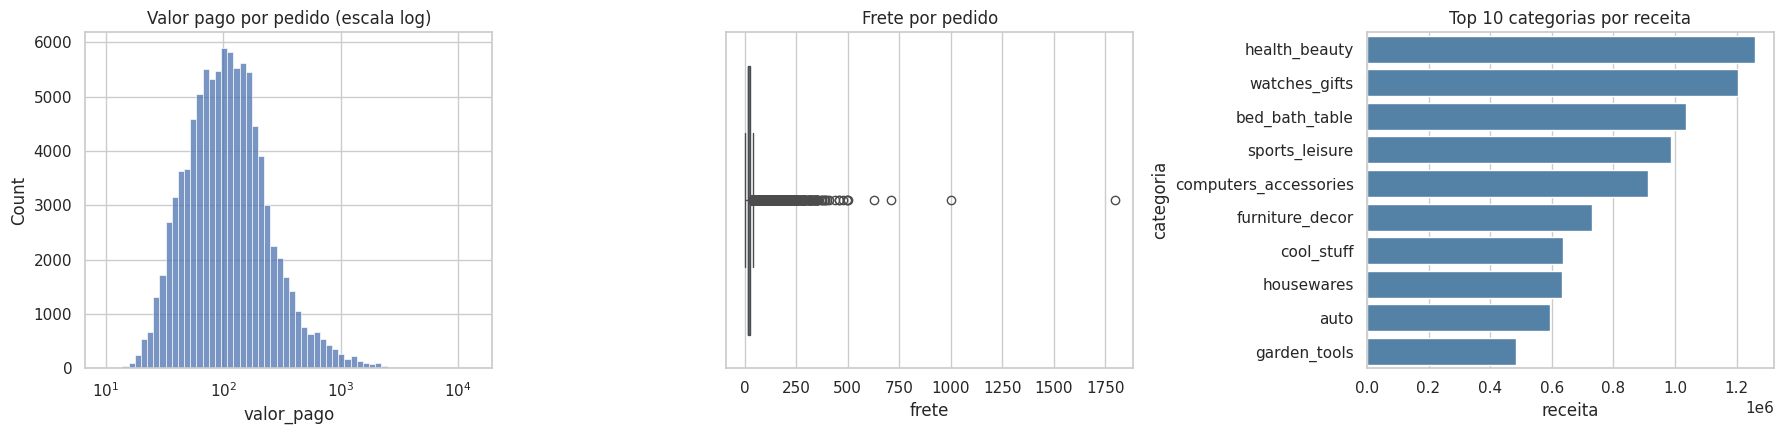

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# Histograma do valor pago em escala log (por causa da assimetria)
sns.histplot(entregues['valor_pago'], bins=60, log_scale=True, ax=ax[0])
ax[0].set_title('Valor pago por pedido (escala log)')

# Boxplot do frete
sns.boxplot(x=entregues['frete'], ax=ax[1])
ax[1].set_title('Frete por pedido')

# Top 10 categorias por receita (reaproveita a lógica da pergunta 3)
cat = q('''
SELECT COALESCE(c.product_category_name_english, pr.product_category_name, 'sem_categoria') AS categoria,
       SUM(i.price) AS receita
FROM itens_pedido i
JOIN produtos pr          ON i.product_id = pr.product_id
LEFT JOIN categorias_en c ON pr.product_category_name = c.product_category_name
GROUP BY categoria ORDER BY receita DESC LIMIT 10
''')
sns.barplot(data=cat, y='categoria', x='receita', ax=ax[2], color='steelblue')
ax[2].set_title('Top 10 categorias por receita')

plt.tight_layout(); plt.show()

## 5. Tempo
Pedidos e receita por mês. Existe pico em novembro (Black Friday)?

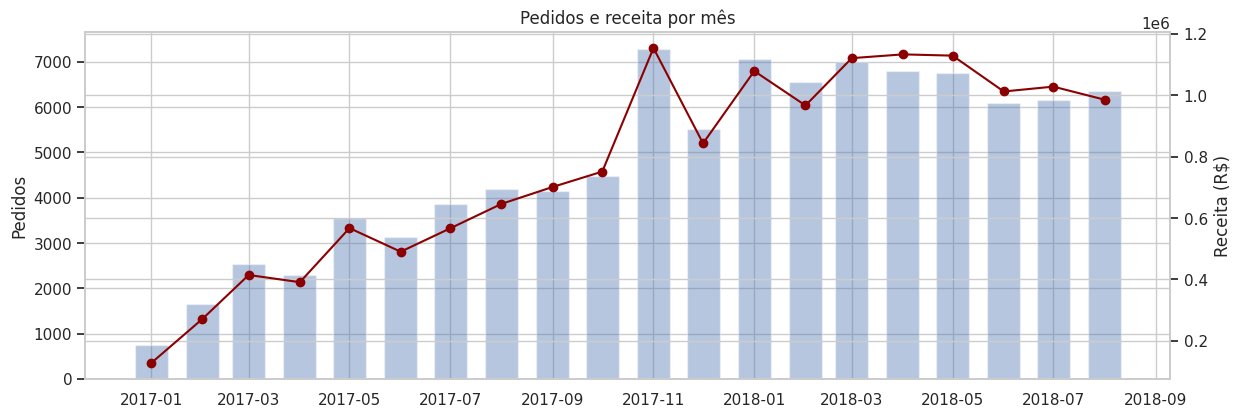

Mês com mais pedidos: 2017-11


In [6]:
entregues['mes'] = entregues['data_compra'].dt.to_period('M').dt.to_timestamp()
mensal = (entregues.groupby('mes')
          .agg(pedidos=('order_id', 'count'), receita=('valor_pago', 'sum'))
          .loc['2017-01':'2018-08'])                # corta as pontas incompletas

fig, ax1 = plt.subplots(figsize=(14, 4.5))
ax1.bar(mensal.index, mensal['pedidos'], width=20, alpha=0.4, label='Pedidos')
ax2 = ax1.twinx()                                   # segundo eixo para a receita
ax2.plot(mensal.index, mensal['receita'], color='darkred', marker='o', label='Receita')
ax1.set_title('Pedidos e receita por mês'); ax1.set_ylabel('Pedidos'); ax2.set_ylabel('Receita (R$)')
plt.show()

print('Mês com mais pedidos:', mensal['pedidos'].idxmax().strftime('%Y-%m'))

## 6. Relações
Atraso × nota da avaliação; frete × distância entre estados; valor × parcelas.

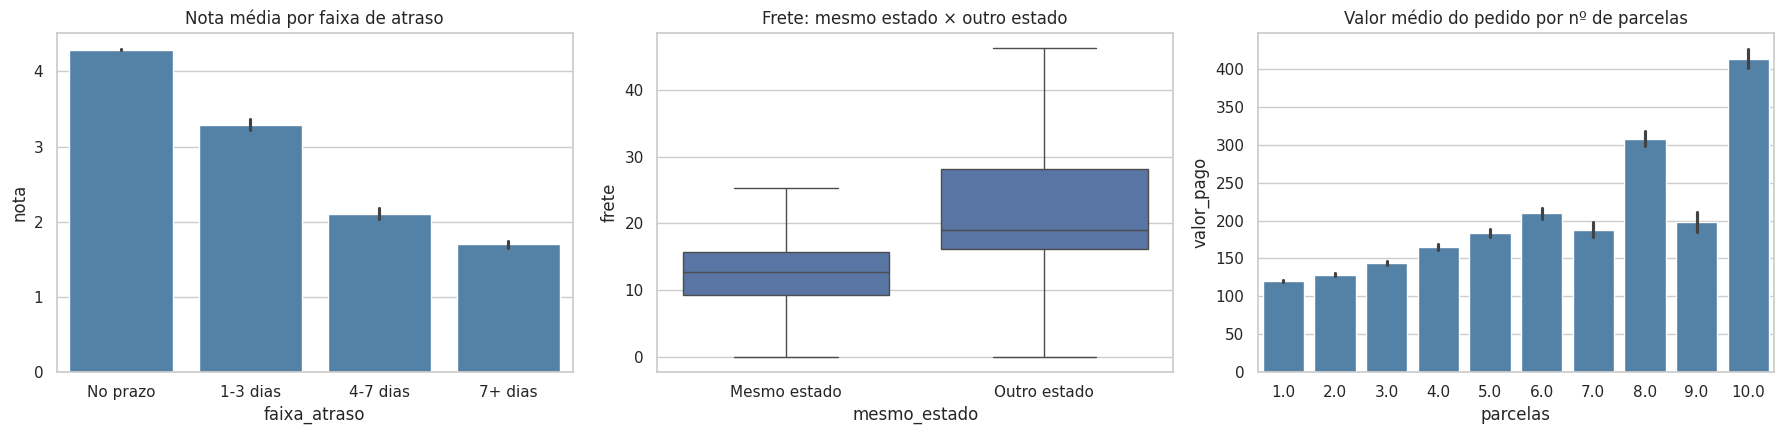

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# 1) Atraso × nota (versão visual da pergunta 6)
entregues['dias_atraso'] = (entregues['data_entrega'].dt.normalize()
                            - entregues['data_estimada'].dt.normalize()).dt.days
entregues['faixa_atraso'] = pd.cut(entregues['dias_atraso'],
                                   bins=[-999, 0, 3, 7, 999],
                                   labels=['No prazo', '1-3 dias', '4-7 dias', '7+ dias'])
sns.barplot(data=entregues, x='faixa_atraso', y='nota', ax=ax[0], color='steelblue')
ax[0].set_title('Nota média por faixa de atraso')

# 2) Frete: vendedor no mesmo estado do cliente × outro estado
entregues['mesmo_estado'] = (entregues['estado_cliente'] == entregues['estado_vendedor']).map(
    {True: 'Mesmo estado', False: 'Outro estado'})
sns.boxplot(data=entregues, x='mesmo_estado', y='frete', ax=ax[1], showfliers=False)
ax[1].set_title('Frete: mesmo estado × outro estado')

# 3) Valor × parcelas
sns.barplot(data=entregues[entregues['parcelas'].between(1, 10)],
            x='parcelas', y='valor_pago', ax=ax[2], color='steelblue')
ax[2].set_title('Valor médio do pedido por nº de parcelas')

plt.tight_layout(); plt.show()

## Principais achados
1.
2.
3.